# ex04 · 训练过程观察（对应教材 3.2 / 3.3）

> **做题流程**：每道题先预测（曲线长什么样、会不会发散），再运行看真实曲线，最后回答问答区。
> **做完再看** `solutions/ex04-答案.md`。
>
> 难度标记：🌱 基础（预测+验证）｜🔧 变式（改动观察）｜🚀 挑战（闭卷复现）
>
> 本节不写新模型，只改超参数观察损失曲线——这是一轮「动手实践」（拟合函数）与「优化器与学习率」面试考点的前奏。

In [10]:
%matplotlib inline
import torch
from torch import nn
from torch.utils import data
import matplotlib.pyplot as plt

torch.manual_seed(0)

def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

def train_linreg(lr, batch_size=10, num_epochs=3, seed=0):
    """用给定超参数训练一个 nn.Linear(2,1)，返回每 epoch 的损失列表"""
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(2, 1))
    loss = nn.MSELoss()
    trainer = torch.optim.SGD(net.parameters(), lr=lr)
    data_iter = load_array((features, labels), batch_size)
    history = []
    for epoch in range(num_epochs):
        for X, y in data_iter:
            l = loss(net(X), y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
        with torch.no_grad():
            l = loss(net(features), labels)
            history.append(float(l))
            print(f'lr={lr}, batch_size={batch_size}, epoch {epoch+1}, loss {l:.6f}')
    return history

## 题 1 🔧 学习率对比：lr ∈ {0.001, 0.01, 0.1, 10}

四个学习率各训练 3 个 epoch（其余超参数相同）。先预测再运行：

- 哪个 lr 收敛最快（3 个 epoch 后 loss 最低）？
- lr=10 会怎样？损失大约到什么数量级？
- 四条曲线大概长什么样（哪条高、哪条抖、哪条飞出去）？

**【你的预测】**
| lr | 3 epoch 后 loss | 现象 |
|---|---|---|
| 0.001 | ~几 | 慢慢下降，3 轮远没收敛 |
| 0.01 | ~0.0x | 稳定下降，速度适中 |
| 0.1 | ~1e-4 级 | 几乎立刻收敛 |
| 10 | inf / nan | **发散**：损失爆炸到溢出变成 inf，进一步变成 nan |


In [11]:
histories = {}
for lr in [0.001, 0.01, 0.1, 10]:
    histories[lr] = train_linreg(lr)

lr=0.001, batch_size=10, epoch 1, loss 27.365625
lr=0.001, batch_size=10, epoch 2, loss 18.423012
lr=0.001, batch_size=10, epoch 3, loss 12.404444
lr=0.01, batch_size=10, epoch 1, loss 0.747230
lr=0.01, batch_size=10, epoch 2, loss 0.014010
lr=0.01, batch_size=10, epoch 3, loss 0.000359
lr=0.1, batch_size=10, epoch 1, loss 0.000094
lr=0.1, batch_size=10, epoch 2, loss 0.000097
lr=0.1, batch_size=10, epoch 3, loss 0.000097
lr=10, batch_size=10, epoch 1, loss nan
lr=10, batch_size=10, epoch 2, loss nan
lr=10, batch_size=10, epoch 3, loss nan


#### lr=10 让每一步都"跳过"最优解且越跳越远，参数指数级爆炸，数值超过 float32 上限变成 inf，inf - inf 得到 NaN。这就是"学习率太大 → 损失发散"的完整过程

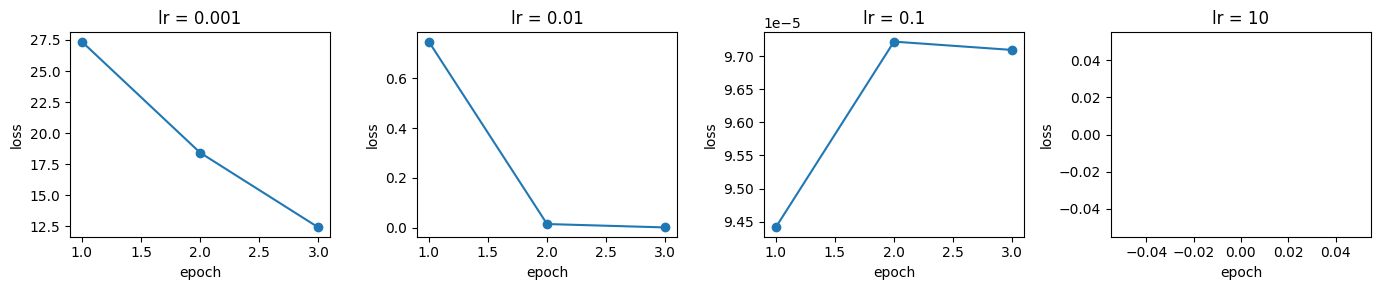

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (lr, hist) in zip(axes, histories.items()):
    ax.plot(range(1, len(hist) + 1), hist, marker='o')
    ax.set_title(f'lr = {lr}')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
plt.tight_layout()
plt.show()

## 题 2 🔧 批大小对比：batch_size ∈ {5, 50, 500}

lr 固定 0.03。先预测：哪个 batch_size 每个 epoch 的更新次数最多？哪条曲线最「抖」？
（提示：batch 越小，用少量样本估计出的梯度噪声越大）

**【你的预测】**

In [13]:
hist_bs = {}
for bs in [5, 50, 500]:
    hist_bs[bs] = train_linreg(0.03, batch_size=bs)

lr=0.03, batch_size=5, epoch 1, loss 0.000094
lr=0.03, batch_size=5, epoch 2, loss 0.000095
lr=0.03, batch_size=5, epoch 3, loss 0.000095
lr=0.03, batch_size=50, epoch 1, loss 3.519075
lr=0.03, batch_size=50, epoch 2, loss 0.306626
lr=0.03, batch_size=50, epoch 3, loss 0.026905
lr=0.03, batch_size=500, epoch 1, loss 31.834827
lr=0.03, batch_size=500, epoch 2, loss 24.929846
lr=0.03, batch_size=500, epoch 3, loss 19.523817


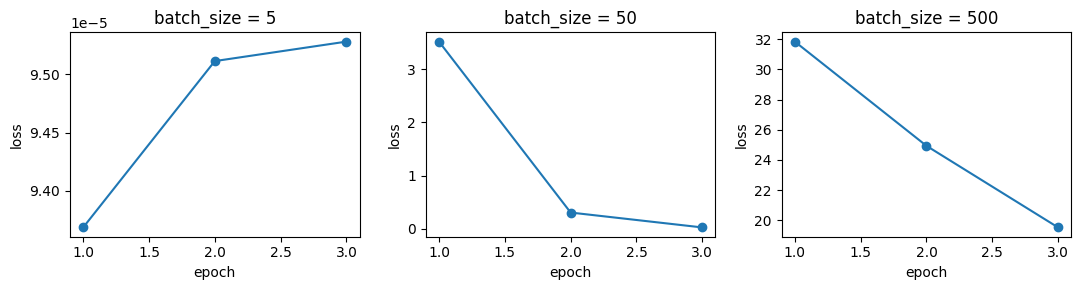

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (bs, hist) in zip(axes, hist_bs.items()):
    ax.plot(range(1, len(hist) + 1), hist, marker='o')
    ax.set_title(f'batch_size = {bs}')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
plt.tight_layout()
plt.show()

| batch_size | 每 epoch 更新次数 | 曲线特征 |
|---|---|---|
| 5 | 200 | 抖、但每 epoch 收敛快 |
| 50 | 20 | 中等 |
| 500 | 2 | 最平滑、但每 epoch 进步最少 |

- **为什么小 batch 抖**：每个 batch 的梯度只用少数样本估计，噪声大，步子方向忽左忽右（抖）；但更新次数多，噪声相互抵消后整体前进快。
- **为什么大 batch 平**：大量样本平均后梯度估计更准，方向稳定；但每 epoch 只更新 2 次，前进慢。
- batch_size 是「每步精度 vs 每步数量」的权衡：小 batch = 走很多小碎步（有噪声），大 batch = 走少数大步（更稳）。

## 题 3 🌱 轮数影响：num_epochs = 10

lr=0.01 训练 10 个 epoch。先预测：loss 会一直下降吗？最后会停在什么水平？

**【你的预测】**

lr=0.01, batch_size=10, epoch 1, loss 0.747230
lr=0.01, batch_size=10, epoch 2, loss 0.014010
lr=0.01, batch_size=10, epoch 3, loss 0.000359
lr=0.01, batch_size=10, epoch 4, loss 0.000098
lr=0.01, batch_size=10, epoch 5, loss 0.000093
lr=0.01, batch_size=10, epoch 6, loss 0.000093
lr=0.01, batch_size=10, epoch 7, loss 0.000093
lr=0.01, batch_size=10, epoch 8, loss 0.000093
lr=0.01, batch_size=10, epoch 9, loss 0.000093
lr=0.01, batch_size=10, epoch 10, loss 0.000093


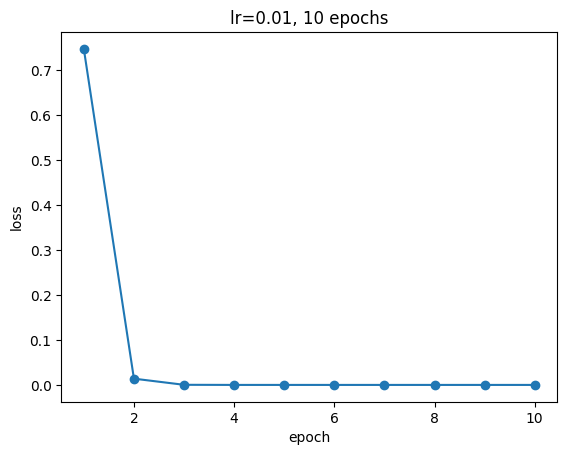

In [15]:
hist_long = train_linreg(0.01, num_epochs=10)
plt.plot(range(1, 11), hist_long, marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('lr=0.01, 10 epochs')
plt.show()

loss 前几个 epoch 快速下降，之后进入**平台期**——越接近最优解，梯度越小，下降越慢。训练曲线「先陡后平」是健康收敛的标志；如果验证损失开始回升，则是过拟合信号

## 问答与小结（先写你的回答）

1. 为什么 lr=10 会发散？（下山步子太大，越过谷底后越走越远）
2. lr 太小的代价是什么？（收敛慢：相同 epoch 数下 loss 还很高）
3. batch_size 小的曲线为什么抖？（梯度噪声大，但每 epoch 更新次数多、收敛反而更快）
4. 这些现象和一轮「优化器与学习率」考点有什么关系？（面试高频）

**【你的预测】**
1. lr=10 发散：步长超过曲率半径，在谷底两侧来回弹射并放大（见上）。
2. lr 太小：收敛慢，同样的 epoch 数损失还很高；实践中可以配学习率调度（ch11）。
3. 小 batch 抖：梯度噪声大；但线性回归这样简单的凸问题里，噪声被大量更新抵消，小 batch 每 epoch 反而收敛更快。
4. 与一轮「优化器与学习率」考点的关系：面试问「为什么梯度要乘学习率」「lr 太大/太小会怎样」「batch_size 的影响」——本节的曲线就是这三个问题最直接的实验证据。

## 小结与面试衔接

- 学习率是训练里最重要的超参数：太小收敛慢，太大会发散
- batch_size 是「精度 vs 速度」的权衡：小 batch 噪声大但每 epoch 更新多；大 batch 平稳但更慢、且可能泛化略差
- 损失曲线是诊断训练的第一工具（ch04 判断过拟合还会用到）